# Часть 1. Сборка с Velvet

Дополнительно проведенный подготовительный этап.

Файлы с локального компьютера были загружены в предварительно созданную на сервере папку input_data на при помощи следующих команд:
```
mkdir -p ~/seminars/sem11/input_data

scp "/mnt/c/Users/Александр/Downloads/genome_assembly_results/"*.fastq studfbmf02_12@calc:~/seminars/sem11/input_data/
```





Создали папку для результатов сборки


```
mkdir -p ~/seminars/sem11/genome_assembly_results/velvet
```



Был написан скрипт run_velvet_kmers.slurm

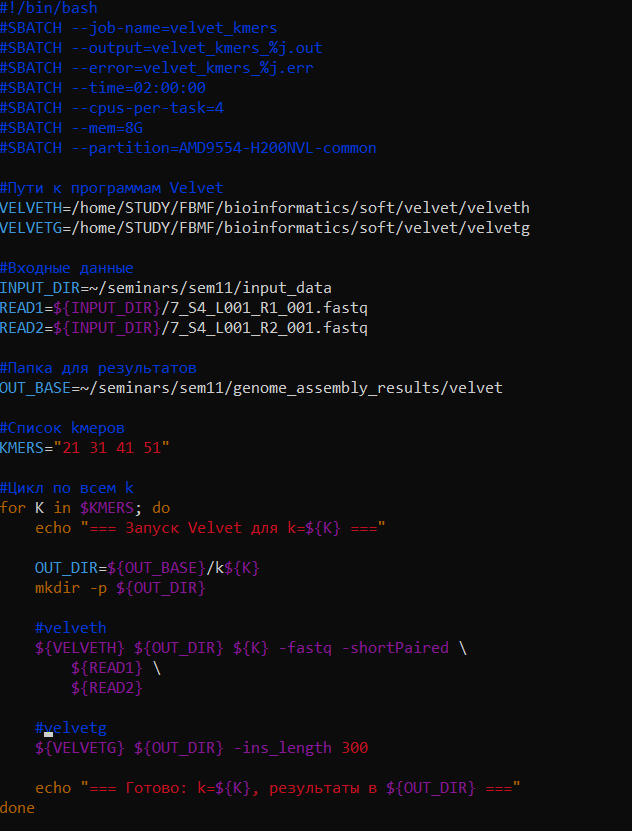

Сделали скриншот папки на сервере c созданными файлами сборки velvet после команды ls -la --time=ctime

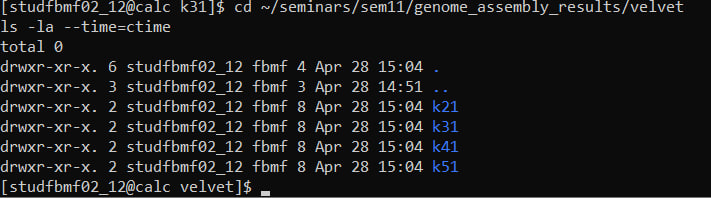

Видим, что появились папки k21, k31, k41, k51 с результатами сборок для соответствующих кмеров.

# Часть 2. Сравнение сборок

Создадим папку для результатов сборки SPAdes.
```
cd ~/seminars/sem11
mkdir -p genome_assembly_results/spades
```
И папку для результатов QUAST
```
cd ~/seminars/sem11
mkdir -p genome_assembly_results/quast_velvet_spades
```



Делаем сборку SPAdes (варианты ркализации через slurm-скрипт представлены в части 3)

In [ ]:
/home/STUDY/FBMF/bioinformatics/soft/SPAdes-4.2.0-Linux/bin/spades.py \
    --careful \
    -k 21,31,41 \
    -1 ~/seminars/sem11/input_data/7_S4_L001_R1_001.fastq \
    -2 ~/seminars/sem11/input_data/7_S4_L001_R2_001.fastq \
    -o ~/seminars/sem11/genome_assembly_results/spades

И запускаем QUAST

In [ ]:
/home/STUDY/FBMF/bioinformatics/soft/bin/quast.py \
    -o assembly_analysis/quast_velvet_spades \
    -m 0 \
    --threads 1 \
    genome_assembly_results/velvet/k21/contigs.fa \
    genome_assembly_results/velvet/k31/contigs.fa \
    genome_assembly_results/velvet/k41/contigs.fa \
    genome_assembly_results/spades/scaffolds.fasta

Файл report.html был скачан на локальный компьютер для просмотра:
```
scp studfbmf02_12@calc:/home/STUDY/FBMF/bioinformatics/your_path/assembly_analysis/quast_spades/report.html .
```

И переименован в report_old.html во избежание путаницы с получаемыми в дальнейшем отчетами.

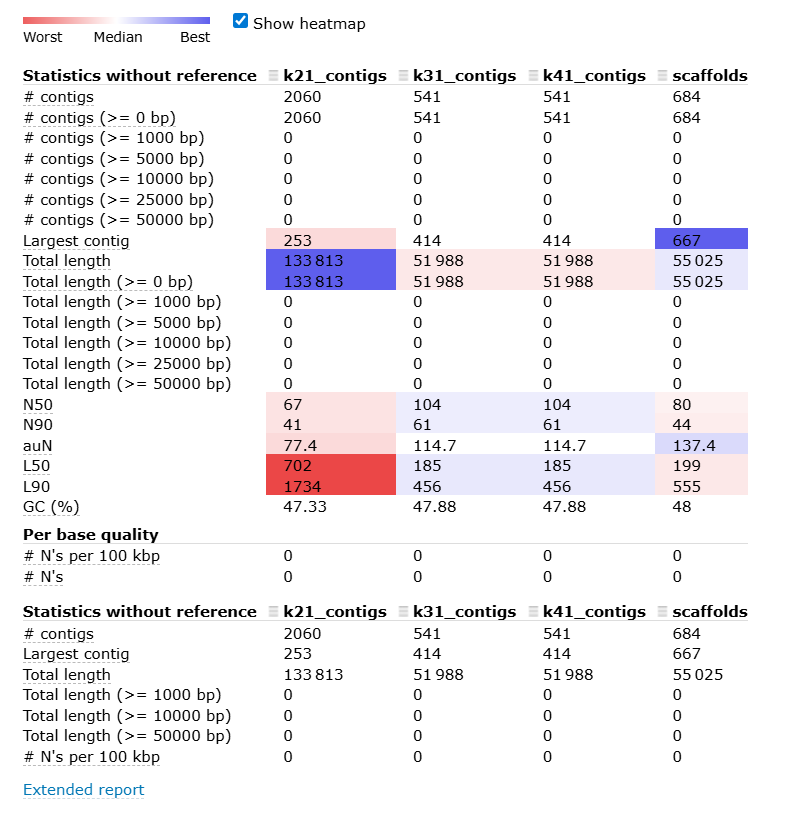

Согласно результатам QUAST, сборки Velvet и SPAdes существенно отличаются по качеству. Velvet при k=21 демонстрирует крайне фрагментированную сборку (2060 контигов, низкие N50 и auN), что делает ее непригодной для анализа. Velvet при k=31 и k=41 показывает более стабильные результаты, однако остается достаточно фрагментированным.

SPAdes формирует более цельную сборку: он дает самый длинный контиг (667 bp), наибольшее значение auN (137.4), а также суммарную длину, наиболее близкую к ожидаемой длине генома. Несмотря на то, что количество контигов у SPAdes немного выше, чем у Velvet k31/k41, интегральные показатели (Largest contig, auN, Total length) указывают на более высокое качество сборки.

Таким образом, лучшей сборкой является SPAdes, поскольку она обеспечивает более длинные контиги, более высокое значение auN и более корректную общую длину сборки, что свидетельствует о меньшей фрагментированности и большей цельности генома.

# Часть 3. Улучшение сборки

Возьмем раннее полученыый scaffold SPAdes и результаты сборки k31, как одной из лучших для Velvet (она не отличается от k41).

Попробуем применить следующие улучшения:
Для сборки Velvet оставляем тот же кмер 31, чтобы сравнение было корректным, но:
включим -exp_cov auto, -cov_cutoff auto(будем автоматически отбрасывать низкопокрытые (шумовые) контиги), чтобы добиться меньшего числа коротких мусорных контигов и более чистой сборки.

Для сборки SPAdes увеличим кмеры -k 21,33,55, чтобы лучше собирались и короткие, и длинные участки.



В папке sem11 написали скрипт run_velvet_new.slurm для новой сборки Velvet

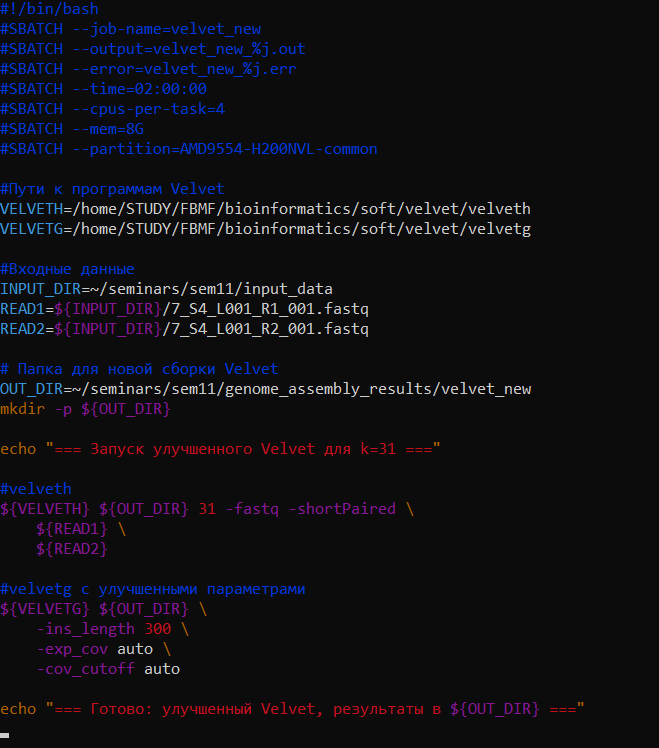

Создаем в папке sem11 скрипт run_spades_new.slurm для новой сборки SPAdes

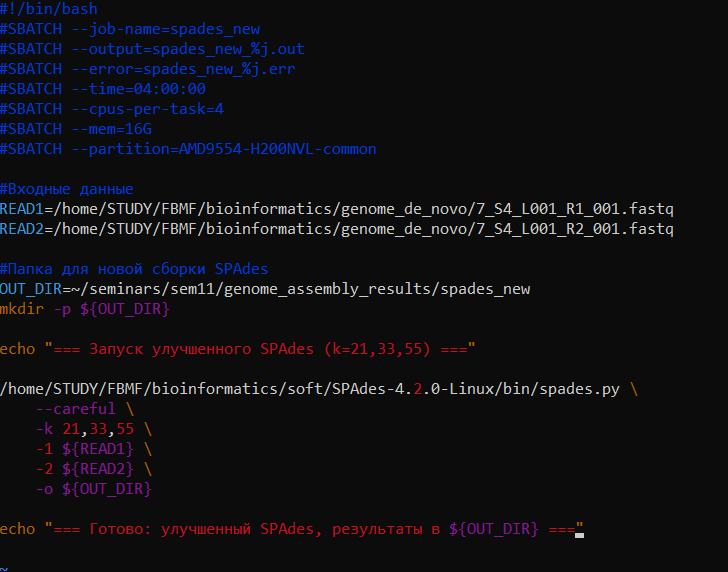

Аналогично, создаем скрипт run_quast_4.slurm для QUAST:

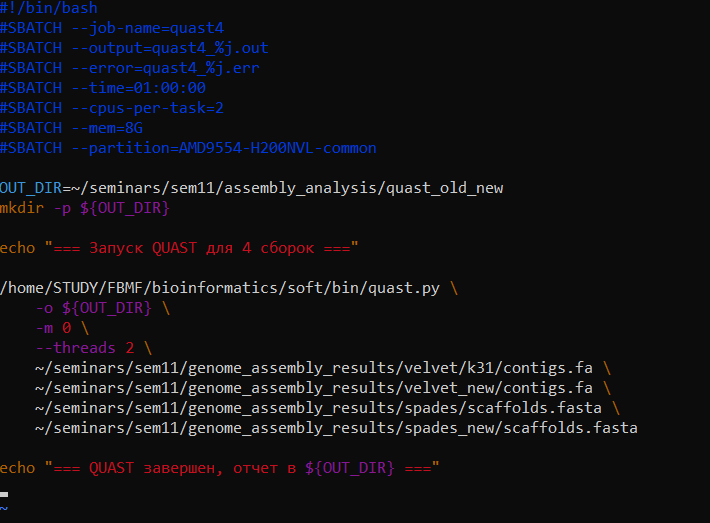

Cкачали report.html на локальный компьютер

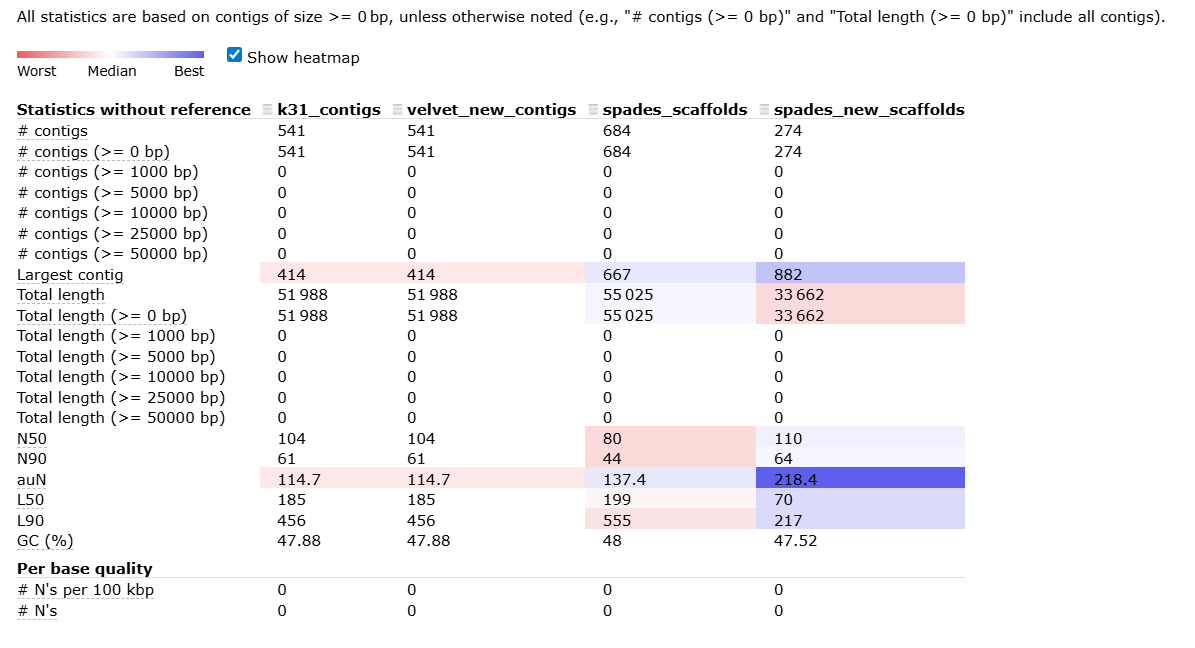

Заметим, что для Velvet # contigs, N50, auN, Largest contigVelvet совпадают со старой версией, что говорит о том, что при данных ридах и k=31, мы достигли предела качества - дальнейшая оптимизация требует изменения k или фильтрации входных данных.

SPAdes же показал отличные результаты:
*   Количество контигов уменьшилось с 684 до 274, т.е. сборка стала более цельной.
*   Крупнейший контиг вырос с 667 до 882, что говорит о том, что улучшилась непрерывность
*   N50 и auN выросли, сборка стала качественнее
*   L50 уменьшился

Все это говорит о том, что новая сборка SPAdes значительно улучшилась - параметры --careful и набор кмеров 21,33,55 дали более длинные и точные контиги.

# Выводы

Среди рассмотренных нами вариантов оптимальным является сборка SPAdes c набором кмеров 21,33,55 и парметром --careful. Из всех рассмотренных вариантов именно этот дает наиболее длинные и точные контиги.